In [1]:
import numpy as np
import json
import pickle

from sklearn.datasets import make_multilabel_classification

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression as BasePredictor

import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [2]:
import sys
sys.path.append("..")

In [3]:
from src.data.formatting import resample_data_set
from src.conformal_risk_control.fnr import compute_prediction_set
from src.model_selection.fnr_oracle import compute_oracle_prediction_set
from src.model_selection.fnr_upper import compute_upper_prediction_set
from src.model_selection.fnr_split import select_predictor_index

In [4]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [5]:
def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

In [6]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_features=params["feature_number"],
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [7]:
params_global = reader("params/experiment_3.json")

{'data': {'sample_size': 1000, 'feature_number': 300, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'base_param': {'C': 10}, 'prop_active_feature': 0.1, 'lam_numbers': [50, 100, 200, 400]}, 'risk': {'control_level': 0.25}}


In [8]:
active_feature_number = np.max([1, np.int64(params_global["data"]["feature_number"] *  params_global["predictor"]["prop_active_feature"])])

In [9]:
active_feature_grids = [
    [] for _ in params_global["predictor"]["lam_numbers"]
]

for lam_number, active_feature_grid in zip(
    params_global["predictor"]["lam_numbers"],
    active_feature_grids
):
    for _ in range(lam_number):
        feature_set = np.arange(params_global["data"]["feature_number"])
        np.random.shuffle(feature_set)
        active_feature_grid.append(
            feature_set[:active_feature_number].copy()
        )

In [10]:
predictors_ = [
    [
        OneVsRestClassifier(BasePredictor(**params_global["predictor"]["base_param"])) for active_feature in active_feature_grid    
    ] for active_feature_grid in active_feature_grids
]

In [11]:
rep_number = 100

In [12]:
results_ = [
        {
        "size":{
            "Oracle":[],
            "Upper":[],
            "Split":[],
            "Output":[],
        }, "FNR":{
            "Oracle":[],
            "Upper":[],
            "Split":[],
        }
    } for _ in predictors_
]

In [ ]:
for predictors, active_feature_grid, results in zip(predictors_, active_feature_grids, results_):
    for rep_index in tqdm(range(rep_number)):
        inputs_, outputs_ = generate_data_set(params_global["data"])
    
        (
            (scaled_inputs_train, outputs_train),
            (scaled_inputs_calibration, outputs_calibration),
            (
                scaled_inputs_selection,
                scaled_inputs_proper_cal,
                outputs_selection,
                outputs_proper_cal,
            ),
            (scaled_input_test, output_test),
        ) = resample_data_set(inputs_, outputs_, params_global["data"]["cal_size"], params_global["data"]["proper_cal_size"])
    
    
        for predictor, active_feature in zip(predictors, active_feature_grid):
            predictor.fit(scaled_inputs_train[:, active_feature], outputs_train)
    
    
        probas_calibration_per_predictor = [
            predictor.predict_proba(scaled_inputs_calibration[:, active_feature])
            for predictor, active_feature in zip(predictors, active_feature_grid)
        ]
        proba_test_per_predictor = [
            predictor.predict_proba(scaled_input_test[:, active_feature])
            for predictor, active_feature in zip(predictors, active_feature_grid)
        ]
        oracle_prediction_set = compute_oracle_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            output_test,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )
    
        
        upper_prediction_set = compute_upper_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )
    
    
    
        probas_selection_per_predictor = [
            predictor.predict_proba(scaled_inputs_selection[:, active_feature])
            for predictor, active_feature in zip(predictors, active_feature_grid)
        ]
        split_predictor_index = select_predictor_index(
            outputs_selection,
            probas_selection_per_predictor,
            params_global["risk"]["control_level"]
        )
        split_prediction_set = compute_prediction_set(
            predictors[split_predictor_index],
            scaled_inputs_proper_cal[:, active_feature_grid[split_predictor_index]],
            outputs_proper_cal,
            scaled_input_test[:, active_feature_grid[split_predictor_index]],
            params_global["risk"]["control_level"]
        )
    
        oracle_fnr = (
            np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        upper_fnr = (
            np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        split_fnr = (
            np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        
        results["FNR"]["Oracle"].append(oracle_fnr)
        results["FNR"]["Upper"].append(upper_fnr)
        results["FNR"]["Split"].append(split_fnr)
    
        results["size"]["Oracle"].append(oracle_prediction_set.sum())
        results["size"]["Upper"].append(upper_prediction_set.sum())
        results["size"]["Split"].append(split_prediction_set.sum())
        results["size"]["Output"].append(output_test.sum())
    
        
        print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
        print("Average output size: {}".format(np.mean(results["size"]["Output"])))
        print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
        print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))


  1%|          | 1/100 [00:04<07:25,  4.50s/it]

Average oracle prediction-set size: 6.0
Average output size: 4.0
Average split prediction-set size: 6.0
Average upper prediction-set size: 6.0


  2%|▏         | 2/100 [00:08<07:06,  4.36s/it]

Average oracle prediction-set size: 5.5
Average output size: 3.0
Average split prediction-set size: 5.5
Average upper prediction-set size: 6.0


  3%|▎         | 3/100 [00:12<06:40,  4.13s/it]

...

Average oracle prediction-set size: 5.242424242424242
Average output size: 3.606060606060606
Average split prediction-set size: 5.424242424242424
Average upper prediction-set size: 6.2272727272727275


 67%|██████▋   | 67/100 [16:35<08:20, 15.16s/it]

Average oracle prediction-set size: 5.268656716417911
Average output size: 3.626865671641791
Average split prediction-set size: 5.447761194029851
Average upper prediction-set size: 6.268656716417911


 68%|██████▊   | 68/100 [16:49<07:57, 14.93s/it]

Average oracle prediction-set size: 5.3088235294117645
Average output size: 3.6323529411764706
Average split prediction-set size: 5.470588235294118
Average upper prediction-set size: 6.294117647058823


In [ ]:
for results in results_:
    print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
    print("Average upper prediction-set      size: {}".format(np.mean(results["size"]["Upper"])))
    print("\n")

Average oracle prediction-set size: 5.49
Average output size: 4.0
Average split prediction-set size: 5.73
Average upper prediction-set      size: 6.89


Average oracle prediction-set size: 5.34
Average output size: 3.64
Average split prediction-set size: 5.93
Average upper prediction-set      size: 6.79


Average oracle prediction-set size: 5.03
Average output size: 4.02
Average split prediction-set size: 5.57
Average upper prediction-set      size: 6.57


Average oracle prediction-set size: 5.21
Average output size: 3.96
Average split prediction-set size: 5.7
Average upper prediction-set      size: 7.06




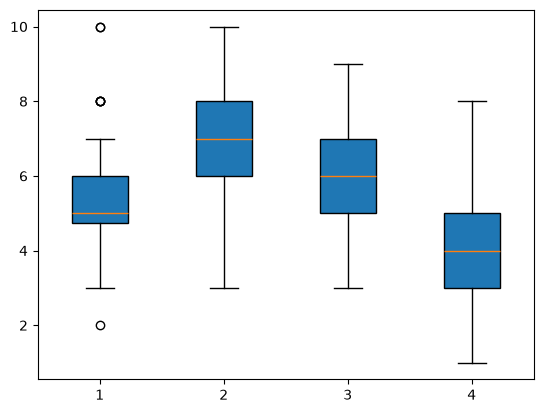

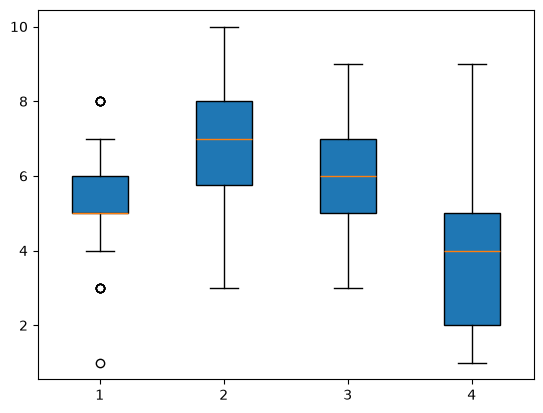

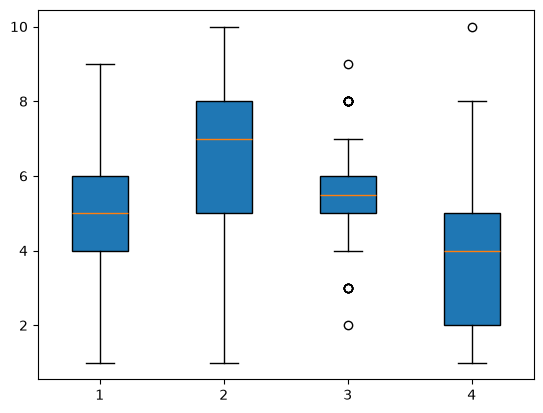

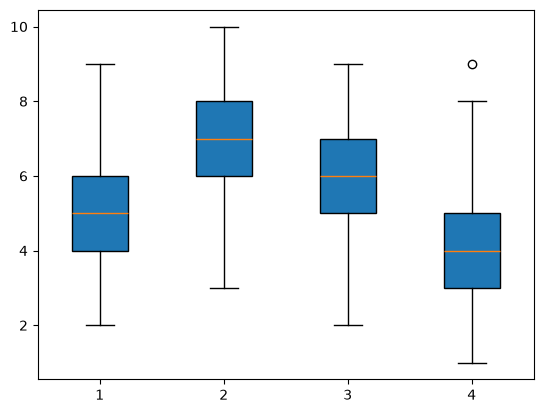

In [ ]:
for results in results_:
    df_volume = pd.DataFrame.from_dict(
        results["size"]
    )     
    fig, ax = plt.subplots()
    box = ax.boxplot(df_volume, patch_artist=True)

In [ ]:
for results in results_:
    print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
    print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))
    print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))
    print("\n")

Average oracle prediction-set FNR: 0.2298333333333333
Average split prediction-set FNR: 0.24576190476190476
Average upper prediction-set FNR: 0.13702380952380952


Average oracle prediction-set FNR: 0.233765873015873
Average split prediction-set FNR: 0.2333730158730159
Average upper prediction-set FNR: 0.14590873015873015


Average oracle prediction-set FNR: 0.28770238095238093
Average split prediction-set FNR: 0.30153571428571424
Average upper prediction-set FNR: 0.18803571428571428


Average oracle prediction-set FNR: 0.22031746031746036
Average split prediction-set FNR: 0.2573095238095238
Average upper prediction-set FNR: 0.1298968253968254




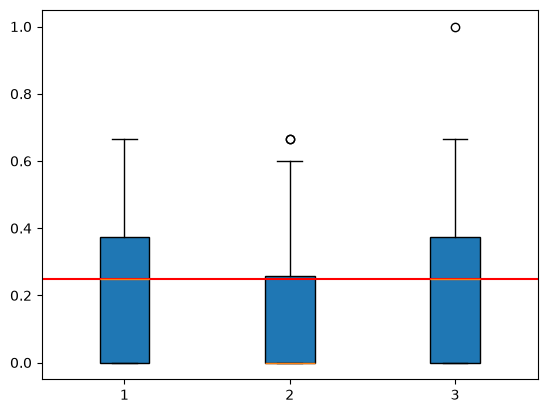

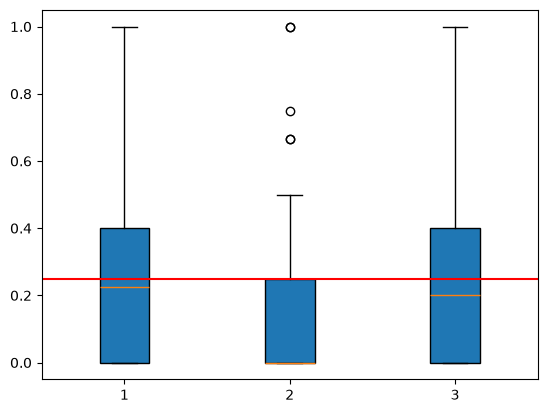

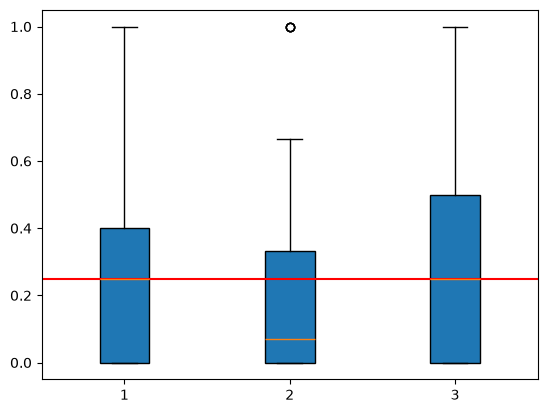

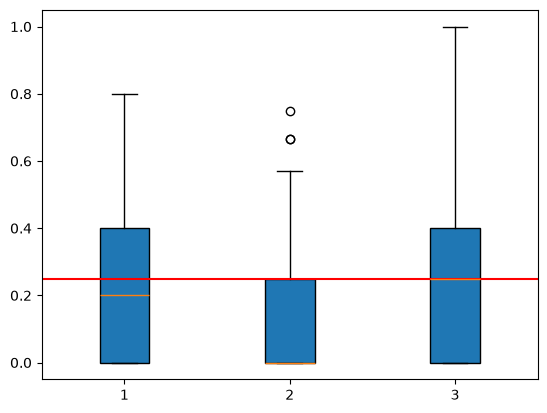

In [ ]:
for results in results_:
    df_fnr = pd.DataFrame.from_dict(
        results["FNR"]
    )
    fig, ax = plt.subplots()
    box = ax.boxplot(df_fnr, patch_artist=True)
    ax.plot(
        [1-0.5, 3+0.5],
        [params_global["risk"]["control_level"], params_global["risk"]["control_level"]],
        color="red"
    )

In [ ]:
result_path = "results/"
result_name = "experiment_3.pkl"
save_list_with_pickle(results_, result_path + result_name)